<a href="https://colab.research.google.com/github/Sophie-S-Z/oblsk-negotiator/blob/main/notebooks/Oblsk_Negotiation_Agent_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oblsk Negotiation Agent

An agent that prices every creator deal and negotiates like a person, with a teammate approving each reply until it earns its way to sending on its own.

This notebook runs the whole thing end to end. It writes the modules to disk, then walks through the pricing thesis, a full negotiation with approvals, a creator the agent hands off, and a sweep across creator types.

Run the cells top to bottom. No keys, no setup.

## 1. Write the modules
Each cell writes one file. In the real repo these live in the `oblsk_negotiator` package; here they are flat so the notebook stands alone.

In [168]:
%%writefile ev_engine.py
"""
The calculator. Prices any deal as a distribution of net value to Oblsk.

Creator views are heavy-tailed: most posts land near the median, a few go far
past it, and the mean sits well above the median because of those few. A model
built on the median alone misses this, which is why it can't see why more videos
from the same creator are worth more. So we fit a samplable view model and run a
Monte Carlo rather than returning a single number.

Two entry points, both pure:
    fit_view_model(post_views)                   -> ViewModel
    ev_distribution(view_model, deal, economics) -> EVResult

Flat per-video pricing only. Cost is fixed and known up front.
"""

from __future__ import annotations

from dataclasses import dataclass, field, asdict
from typing import Optional, Literal
import numpy as np
from scipy import stats


@dataclass(frozen=True)
class CreatorEconomics:
    """Revenue-side assumptions, from the client config rather than the agent."""
    conversion_rate: float      # fraction of views that convert
    ltv_usd: float              # value of one converted customer

    @property
    def revenue_per_view(self) -> float:
        return self.conversion_rate * self.ltv_usd


@dataclass(frozen=True)
class Deal:
    """A flat deal: pay flat_per_video per video, fixed, whatever the views do.

    The non-price levers cost the client close to nothing and carry real value to
    the creator, so they can close a small gap without moving the headline number.
    """
    video_count: int
    flat_per_video: float = 0.0

    usage_rights_months: int = 0
    whitelisting: bool = False
    net_terms_days: int = 30
    deposit_upfront_pct: float = 0.0

    @property
    def total_usd(self) -> float:
        return self.flat_per_video * self.video_count

    @property
    def effective_per_video(self) -> float:
        return self.flat_per_video


DealStructure = Deal  # alias kept for older call sites


DistFamily = Literal["lognormal", "pareto_lognorm", "empirical_prior"]


@dataclass
class ViewModel:
    """A fitted, samplable model of one creator's per-video views."""
    family: DistFamily
    params: dict
    n_posts_fit: int
    median_views: float
    notes: str = ""

    def sample(self, n: int, rng: np.random.Generator) -> np.ndarray:
        if self.family == "lognormal":
            mu, sigma = self.params["mu"], self.params["sigma"]
            return rng.lognormal(mean=mu, sigma=sigma, size=n)

        if self.family == "pareto_lognorm":
            mu, sigma = self.params["mu"], self.params["sigma"]
            alpha, x_min = self.params["alpha"], self.params["x_min"]
            tail_frac = self.params["tail_frac"]
            body = rng.lognormal(mean=mu, sigma=sigma, size=n)
            is_tail = rng.random(n) < tail_frac
            n_tail = int(is_tail.sum())
            if n_tail:
                body[is_tail] = (rng.pareto(alpha, size=n_tail) + 1.0) * x_min
            return body

        if self.family == "empirical_prior":
            prior = self.params["prior_samples"]
            scale = self.params.get("scale", 1.0)
            idx = rng.integers(0, len(prior), size=n)
            return prior[idx] * scale

        raise ValueError(f"unknown family {self.family!r}")

    def coefficient_of_variation(self, seed: int = 7, n: int = 5000) -> float:
        rng = np.random.default_rng(seed)
        s = self.sample(n, rng)
        return float(s.std() / s.mean()) if s.mean() > 0 else 0.0


def fit_view_model(
    post_views: list[float] | np.ndarray,
    *,
    min_posts: int = 6,
    prior_samples: Optional[np.ndarray] = None,
    tier_median: Optional[float] = None,
) -> ViewModel:
    """Fit a samplable view model to a creator's recent per-video views.

    With enough history, fit a log-normal by MLE on log(views) and splice on a
    Pareto tail when the tail is heavier than log-normal allows (positive excess
    kurtosis in log space, alpha from a Hill estimate). With too little history,
    fall back to a tier prior scaled to whatever real posts exist.
    """
    v = np.asarray([x for x in post_views if x is not None and x > 0], dtype=float)
    n = len(v)

    if n < min_posts:
        if prior_samples is not None and len(prior_samples) > 0:
            scale = 1.0
            if n > 0 and tier_median is None:
                scale = float(np.median(v)) / float(np.median(prior_samples))
            elif tier_median is not None:
                scale = float(tier_median) / float(np.median(prior_samples))
            return ViewModel(
                family="empirical_prior",
                params={"prior_samples": np.asarray(prior_samples, float),
                        "scale": scale},
                n_posts_fit=n,
                median_views=float(np.median(prior_samples) * scale),
                notes=f"fallback prior ({n} posts, need {min_posts}); scaled x{scale:.2f}")
        if n == 0:
            raise ValueError("no usable post views and no prior provided")
        log_v = np.log(v)
        mu = float(log_v.mean())
        sigma = float(max(log_v.std(ddof=1) if n > 1 else 0.9, 0.9))
        return ViewModel(
            family="lognormal", params={"mu": mu, "sigma": sigma},
            n_posts_fit=n, median_views=float(np.exp(mu)),
            notes=f"thin data ({n} posts), inflated sigma, no prior")

    log_v = np.log(v)
    mu = float(log_v.mean())
    sigma = float(log_v.std(ddof=1))
    log_kurt = float(stats.kurtosis(log_v, fisher=True, bias=False)) if n >= 4 else 0.0

    if log_kurt > 1.0 and n >= 10:
        x_min = float(np.quantile(v, 0.90))
        tail = v[v >= x_min]
        if len(tail) >= 3:
            alpha = float(np.clip(len(tail) / np.sum(np.log(tail / x_min)), 1.2, 4.0))
            tail_frac = float(len(tail) / n)
            return ViewModel(
                family="pareto_lognorm",
                params={"mu": mu, "sigma": sigma, "alpha": alpha,
                        "x_min": x_min, "tail_frac": tail_frac},
                n_posts_fit=n, median_views=float(np.exp(mu)),
                notes=f"lognormal body + Pareto tail (alpha={alpha:.2f}, "
                      f"x_min={x_min:.0f}, tail_frac={tail_frac:.2f})")

    return ViewModel(
        family="lognormal", params={"mu": mu, "sigma": sigma},
        n_posts_fit=n, median_views=float(np.exp(mu)),
        notes=f"lognormal MLE (log-kurtosis={log_kurt:.2f})")


@dataclass
class EVResult:
    """Distribution of net value to Oblsk for one deal."""
    revenue_p10: float
    revenue_p50: float
    revenue_p90: float
    revenue_mean: float
    cost_total: float
    net_p10: float
    net_p50: float
    net_p90: float
    net_mean: float
    roi_mean: float
    prob_net_positive: float
    deal: dict = field(default_factory=dict)
    view_model_notes: str = ""

    def summary(self) -> str:
        return (f"net mean ${self.net_mean:,.0f}  "
                f"[p10 ${self.net_p10:,.0f} .. p90 ${self.net_p90:,.0f}]  "
                f"cost ${self.cost_total:,.0f}  ROI {self.roi_mean:.1f}x  "
                f"P(net>0) {self.prob_net_positive:.0%}")


def ev_distribution(
    view_model: ViewModel,
    deal: Deal,
    econ: CreatorEconomics,
    *,
    n_samples: int = 5000,
    seed: Optional[int] = None,
) -> EVResult:
    """Monte Carlo. For each draw: sample views for every video, turn them into
    attributed revenue, subtract the fixed cost, record the net. Pure given seed.
    """
    rng = np.random.default_rng(seed)
    k = deal.video_count
    if k <= 0:
        raise ValueError("video_count must be >= 1")

    views = view_model.sample(n_samples * k, rng).reshape(n_samples, k)
    revenue = views.sum(axis=1) * econ.revenue_per_view
    cost_total = float(deal.total_usd)
    net = revenue - cost_total

    def pct(a, q):
        return float(np.percentile(a, q))

    roi = float(revenue.mean() / cost_total) if cost_total > 1e-9 else float("inf")
    return EVResult(
        revenue_p10=pct(revenue, 10), revenue_p50=pct(revenue, 50),
        revenue_p90=pct(revenue, 90), revenue_mean=float(revenue.mean()),
        cost_total=cost_total,
        net_p10=pct(net, 10), net_p50=pct(net, 50),
        net_p90=pct(net, 90), net_mean=float(net.mean()),
        roi_mean=roi, prob_net_positive=float((net > 0).mean()),
        deal=asdict(deal), view_model_notes=view_model.notes)


def synthetic_tier_prior(tier_median: float, sigma: float = 0.8,
                         size: int = 2000, seed: int = 0) -> np.ndarray:
    """Stand-in tier prior for testing. In production this is built from real
    historical views across creators in the same platform and follower tier."""
    rng = np.random.default_rng(seed)
    return rng.lognormal(mean=np.log(tier_median), sigma=sigma, size=size)


Overwriting ev_engine.py


In [169]:
%%writefile bundles.py
"""
Deal library. Builds the deals the negotiator weighs. Pure: returns deals, does
not score them.

The negotiator uses two in order:
    flat_offer       the opening move, one video at a fair rate
    bundle_from_flat the escalation, more videos at the same fair per-video rate
Plus small non-price sweeteners (faster pay, usage rights, whitelisting).
"""

from __future__ import annotations

from dataclasses import replace
from ev_engine import Deal


def flat_offer(total_usd: float, video_count: int = 1) -> Deal:
    return Deal(video_count=video_count, flat_per_video=total_usd / video_count)


def same_total_repackage(total_usd: float, video_counts=(1, 2, 3, 4)) -> list[Deal]:
    """Hold the total roughly constant, vary the video count. Same headline
    number to the creator, more content and more draws for us.

    Note: this collapses per-video pay as the count rises, so a real creator will
    not accept the higher-count versions. It exists only to isolate the effect of
    extra draws on Oblsk's side; do not use it to construct an actual offer."""
    return [Deal(video_count=k, flat_per_video=total_usd / k) for k in video_counts]


def bundle_from_flat(flat: Deal, *, target_videos: int = 3,
                     bulk_discount: float = 0.10) -> Deal:
    """Turn a one-video flat offer into the bundle we escalate to.

    Keep the per-video rate close to the flat rate (a small bulk discount is
    standard for committing to several videos at once) and let the total scale
    with the video count. Each added video is another independent draw from the
    tail, so Oblsk's absolute net value scales with the count while the creator
    is still paid fairly per video. The creator sees a bigger headline number
    *and* a fair rate, so it is an offer they will actually accept."""
    per_video = flat.effective_per_video * (1.0 - bulk_discount)
    return Deal(video_count=target_videos, flat_per_video=per_video)


def add_non_price_sweetener(deal: Deal, lever: str) -> Deal:
    if lever == "fast_pay":
        return replace(deal, net_terms_days=15, deposit_upfront_pct=0.25)
    if lever == "usage_rights":
        return replace(deal, usage_rights_months=6)
    if lever == "whitelisting":
        return replace(deal, whitelisting=True)
    raise ValueError(f"unknown lever {lever!r}")


LEVER_PITCH = {
    "fast_pay": "we can move you to net-15 with 25% upfront",
    "usage_rights": "we'll keep usage rights to 6 months instead of a longer window",
    "whitelisting": "we can add whitelisting so the content keeps working for you",
}


Overwriting bundles.py


In [170]:
%%writefile state.py
"""
Conversation state. One DB row per thread, extending negotiationConversation.

Two ideas matter:
  autonomy_level  in human_approval the agent proposes and waits; in autonomous
                  the same proposals send on their own. Flipping it is how the
                  human comes out of the loop later, with no rewrite.
  phase           where the conversation is: questions, opening flat, negotiating,
                  closing.

State serializes and deserializes cleanly so the agent can pause and resume, and
it detects when a human steps into the thread.
"""

from __future__ import annotations

from dataclasses import dataclass, field, asdict
from enum import Enum
from typing import Optional
import json


class Status(str, Enum):
    OPEN = "open"
    ESCALATED = "escalated"
    ACCEPTED = "accepted"
    REJECTED = "rejected"
    STALE = "stale"


class Phase(str, Enum):
    QA = "qa"
    OPENING = "opening"
    NEGOTIATING = "negotiating"
    CLOSING = "closing"


class AutonomyLevel(str, Enum):
    HUMAN_APPROVAL = "human_approval"
    AUTONOMOUS = "autonomous"


@dataclass
class ConcessionRecord:
    round: int
    offered_total: float
    offered_video_count: int
    asked_for: Optional[float]
    deal: dict


@dataclass
class ApprovalRecord:
    round: int
    action: str
    proposed_total: Optional[float]
    outcome: str                     # approved | rejected | edited | auto
    note: str = ""


@dataclass
class NegotiationState:
    creator_id: str
    campaign_id: str
    thread_id: str

    autonomy_level: AutonomyLevel = AutonomyLevel.HUMAN_APPROVAL
    ev_snapshot: dict = field(default_factory=dict)

    phase: Phase = Phase.QA
    round_count: int = 0
    max_rounds: int = 3
    questions_answered: int = 0
    flat_offer_made: bool = False
    bundle_offered: bool = False

    concession_history: list[ConcessionRecord] = field(default_factory=list)
    approval_history: list[ApprovalRecord] = field(default_factory=list)

    last_human_touch_at: Optional[float] = None
    last_agent_message_at: Optional[float] = None
    last_thread_sender: str = "creator"

    status: Status = Status.OPEN
    final_total: Optional[float] = None
    final_deal: Optional[dict] = None
    escalation_reason: Optional[str] = None

    creator_first_ask: Optional[float] = None
    notes: list[str] = field(default_factory=list)

    def to_json(self) -> str:
        d = asdict(self)
        d["autonomy_level"] = self.autonomy_level.value
        d["phase"] = self.phase.value
        d["status"] = self.status.value
        return json.dumps(d)

    @classmethod
    def from_json(cls, s: str) -> "NegotiationState":
        d = json.loads(s)
        d["autonomy_level"] = AutonomyLevel(d["autonomy_level"])
        d["phase"] = Phase(d["phase"])
        d["status"] = Status(d["status"])
        d["concession_history"] = [ConcessionRecord(**c) for c in d["concession_history"]]
        d["approval_history"] = [ApprovalRecord(**a) for a in d["approval_history"]]
        return cls(**d)

    def human_intervened(self, thread_last_sender: str, thread_last_ts: float) -> bool:
        """True when a person sent the most recent message after the agent did."""
        if thread_last_sender == "human":
            if (self.last_agent_message_at is None or
                    thread_last_ts > self.last_agent_message_at):
                return True
        return False

    def record_concession(self, deal_dict: dict, total: float,
                          creator_ask: Optional[float]):
        self.concession_history.append(ConcessionRecord(
            round=self.round_count, offered_total=total,
            offered_video_count=deal_dict.get("video_count", 1),
            asked_for=creator_ask, deal=deal_dict))

    def record_approval(self, action: str, proposed_total: Optional[float],
                        outcome: str, note: str = ""):
        self.approval_history.append(ApprovalRecord(
            round=self.round_count, action=action,
            proposed_total=proposed_total, outcome=outcome, note=note))


Overwriting state.py


In [171]:
%%writefile qa.py
"""
Q&A mode. Answers a creator's questions before any rate is on the table:
deliverables, timeline, usage, payment, and anything off-topic. A budget
question is the signal to move to an offer.

answer_from_brief is deterministic and runs with no network (Colab, tests, and a
safe fallback). build_qa_llm_prompt is the prompt for the production model, which
handles open-ended questions in the same voice and never quotes a rate.
"""

from __future__ import annotations

from dataclasses import dataclass, field


@dataclass
class CampaignBrief:
    """The facts the Q&A layer answers from. Populated from the campaign config in
    production; defaults here keep the demo runnable."""
    brand: str = "the brand"
    product: str = "the product"
    platform: str = "Instagram"
    content_type: str = "a Reel"
    deliverables: str = "one in-feed Reel, 30 to 60 seconds, plus a story frame"
    timeline: str = "about two weeks from when we lock the brief"
    usage_rights: str = "6 months of organic usage, no paid whitelisting unless we agree to it"
    exclusivity: str = "no category exclusivity, you can work with others outside this brand"
    revisions: str = "one round of revisions, we keep notes light"
    payment_terms: str = "net-30 after the content goes live, faster pay available"
    creative_freedom: str = "you have creative control, we share a few talking points and let you run with it"
    extra_facts: dict = field(default_factory=dict)


_TOPIC_KEYWORDS = {
    "deliverables": ["deliverable", "how many", "what do i", "what would i",
                     "post", "reel", "video", "story", "content", "make"],
    "timeline": ["when", "deadline", "due", "timeline", "how long", "turnaround"],
    "usage_rights": ["usage", "rights", "own", "ownership", "repost", "reuse",
                     "whitelist", "ads", "boost"],
    "exclusivity": ["exclusive", "exclusivity", "compete", "competitor", "other brand"],
    "revisions": ["revision", "edit", "change", "approve", "approval", "feedback"],
    "payment_terms": ["payment", "invoice", "net-", "net ", "deposit", "upfront",
                      "paid", "when do i get"],
    "creative_freedom": ["creative", "script", "say", "freedom", "control",
                         "talking point", "guideline"],
    "product": ["product", "brand", "who is", "what is", "about the", "company"],
    "budget": ["budget", "rate", "how much", "pay me", "fee", "price", "cost",
               "does this pay"],
}


def classify_question_topic(question: str) -> str:
    """Best-matching topic, or 'general'. Budget wins on ties so money questions
    always route to the offer."""
    q = question.lower()
    if any(kw in q for kw in _TOPIC_KEYWORDS["budget"]):
        return "budget"
    best, best_hits = "general", 0
    for topic, kws in _TOPIC_KEYWORDS.items():
        if topic == "budget":
            continue
        hits = sum(1 for kw in kws if kw in q)
        if hits > best_hits:
            best, best_hits = topic, hits
    return best


def signals_ready_for_offer(question: str) -> bool:
    return classify_question_topic(question) == "budget"


def answer_from_brief(question: str, brief: CampaignBrief) -> str:
    topic = classify_question_topic(question)
    if topic == "budget":
        return ("Good question. Let me put together a number that fits what we are "
                "asking for and send it right over.")
    answers = {
        "deliverables": f"For this one we are looking at {brief.deliverables}.",
        "timeline": f"Timeline is {brief.timeline}.",
        "usage_rights": f"On usage, {brief.usage_rights}.",
        "exclusivity": f"On exclusivity, {brief.exclusivity}.",
        "revisions": f"For revisions, {brief.revisions}.",
        "payment_terms": f"On payment, {brief.payment_terms}.",
        "creative_freedom": f"On the creative, {brief.creative_freedom}.",
        "product": (f"It is for {brief.brand}, promoting {brief.product}. Happy to "
                    f"share more from the brief if useful."),
    }
    if topic in answers:
        return answers[topic]
    if question.strip().lower() in brief.extra_facts:
        return brief.extra_facts[question.strip().lower()]
    return ("Happy to help with that. I can walk you through the deliverables, "
            "timeline, usage, or anything else on your mind, just let me know.")


def build_qa_llm_prompt(question: str, brief: CampaignBrief,
                        thread_history: str = "") -> dict:
    facts = "\n".join([
        f"Brand: {brief.brand}", f"Product: {brief.product}",
        f"Platform: {brief.platform}", f"Deliverables: {brief.deliverables}",
        f"Timeline: {brief.timeline}", f"Usage rights: {brief.usage_rights}",
        f"Exclusivity: {brief.exclusivity}", f"Revisions: {brief.revisions}",
        f"Payment: {brief.payment_terms}", f"Creative: {brief.creative_freedom}"])
    system = (
        "You are an experienced influencer-marketing account manager answering a "
        "creator's question over email or DM. Warm, brief, real. Never reveal or "
        "imply you are an AI. Use only the campaign facts provided; if you do not "
        "know something, say you will check. Never quote a rate or budget; if asked "
        "about money, say you will send a number shortly. Under 90 words.")
    user = [f"Campaign facts:\n{facts}", f"\nCreator asked: {question}"]
    if thread_history:
        user.append(f"\nPrior thread (for tone):\n{thread_history}")
    user.append("\nWrite only the reply.")
    return {"system": system, "user": "\n".join(user)}


Overwriting qa.py


In [172]:
%%writefile behavior_tree.py
"""
Behavior tree for the conversation side.

One pass per inbound message. The first branch that matches fires. The tree
reads the calculator's output and never does pricing math itself. The diagram in
figures/ is drawn from this file, so keep them in step.

Order of branches:
  human stepped in            -> pause, hand back
  creator accepted            -> lock terms
  creator asked a question    -> answer, stay in Q&A
  no offer yet                -> open with one flat number
  their ask is fine for us    -> accept
  their ask is wildly high     -> escalate to a person
  out of rounds               -> escalate to a person
  flat was rejected           -> escalate to a bundle (one offer)
  bundle on the table         -> add a sweetener, else escalate
"""

from __future__ import annotations

from dataclasses import dataclass, asdict
from enum import Enum
from typing import Optional

from ev_engine import CreatorEconomics, Deal, ViewModel, ev_distribution, EVResult
from bundles import flat_offer, bundle_from_flat, add_non_price_sweetener
from state import NegotiationState, Status, Phase, AutonomyLevel
from qa import CampaignBrief, answer_from_brief, classify_question_topic


class Intent(str, Enum):
    QUESTION = "question"
    INTERESTED = "interested"        # engaged, no number yet
    NEGOTIATING = "negotiating"      # has a concrete ask
    ACCEPTED = "accepted"
    REJECTING = "rejecting"
    UNCLEAR = "unclear"


@dataclass
class CreatorMessage:
    intent: Intent
    ask_total_usd: Optional[float] = None
    ask_video_count: Optional[int] = None
    raw_text: str = ""


@dataclass
class CampaignContext:
    """Per-campaign knobs."""
    time_pressure: bool = False
    alternatives_available: bool = True
    auto_send_dollar_ceiling: float = 3000.0  # above this, a person signs off
    roi_hurdle: float = 3.0                    # min revenue/cost multiple
    pay_fraction: float = 0.30                 # opening flat as share of EV/video
    accept_margin: float = 1.05                # accept asks within this of our max
    extreme_ask_multiple: float = 2.0          # above this multiple, escalate


class Action(str, Enum):
    ANSWER_QUESTION = "answer_question"
    OPENING_FLAT = "opening_flat"
    ESCALATE_BUNDLE = "escalate_bundle"
    ADD_SWEETENER = "add_sweetener"
    ACCEPT = "accept"
    SOFT_CLOSE = "soft_close"
    ESCALATE_HUMAN = "escalate_human"     # hand the thread to a person
    PAUSE_HUMAN = "pause_human"           # a person stepped in mid-thread


# Actions that send a message to the creator (so they pass through approval).
_OUTBOUND = {
    Action.ANSWER_QUESTION, Action.OPENING_FLAT, Action.ESCALATE_BUNDLE,
    Action.ADD_SWEETENER, Action.ACCEPT, Action.SOFT_CLOSE,
}


@dataclass
class Decision:
    action: Action
    deal: Optional[Deal]
    ev: Optional[EVResult]
    rationale: str                       # internal, for the reviewer
    requires_approval: bool = False
    answer_text: Optional[str] = None    # for ANSWER_QUESTION
    non_price_lever: Optional[str] = None
    reserve_deal: Optional[Deal] = None  # what we would reveal next if rejected
    reserve_ev: Optional[EVResult] = None


def _requires_approval(action: Action, total: Optional[float],
                       state: NegotiationState, ctx: CampaignContext) -> bool:
    if action == Action.ESCALATE_HUMAN:
        return True
    if action not in _OUTBOUND:
        return False
    if state.autonomy_level == AutonomyLevel.HUMAN_APPROVAL:
        return True
    return total is not None and total > ctx.auto_send_dollar_ceiling


# ---- valuation: read the calculator, decide what we will pay ----------------

def _round_money(x: float, step: float = 50.0) -> float:
    """Round an offer to a clean number, the way a person would write it."""
    return float(round(x / step) * step)


def _fair_flat_total(vm: ViewModel, econ: CreatorEconomics,
                     ctx: CampaignContext) -> float:
    """What we will pay for one video: a slice of the expected revenue it drives,
    floored so it never goes silly-low on a small creator."""
    exp_rev_per_video = vm.median_views * econ.revenue_per_view
    return max(250.0, ctx.pay_fraction * exp_rev_per_video)


def _flat_total(vm, econ, ctx) -> float:
    return _round_money(_fair_flat_total(vm, econ, ctx), 50.0)


def _max_pay_per_video(vm, econ, ctx) -> float:
    """Oblsk's ceiling: the most per video that still clears the ROI hurdle. Uses
    the same conservative (median-based) revenue proxy as the opening flat, so the
    agent never pays a rate that the campaign cannot justify on the numbers."""
    exp_rev_per_video = vm.median_views * econ.revenue_per_view
    if ctx.roi_hurdle <= 0:
        return exp_rev_per_video
    return exp_rev_per_video / ctx.roi_hurdle


# A small bulk discount the creator grants for committing to several videos at
# once. Off our own fair rate when we anchor there; a lighter touch when we anchor
# to the creator's revealed ask, so the rate still clears their (private) floor.
_BUNDLE_BULK_DISCOUNT = 0.10
_ASK_BULK_DISCOUNT = 0.05


def _bundle_per_video(vm, econ, ctx, ask_per_video: Optional[float] = None) -> float:
    """The per-video rate for a bundle. Pay our fair rate (less a bulk discount);
    if the creator has revealed a higher per-video ask, meet them just under it so
    the rate is one they will actually accept. Never exceed the ROI ceiling."""
    fair = _fair_flat_total(vm, econ, ctx)
    floor = fair * (1.0 - _BUNDLE_BULK_DISCOUNT)
    target = floor
    if ask_per_video:
        target = max(floor, ask_per_video * (1.0 - _ASK_BULK_DISCOUNT))
    return min(target, _max_pay_per_video(vm, econ, ctx))


def _bundle_total(vm, econ, ctx, ask_per_video: Optional[float] = None,
                  target_videos: int = 3) -> float:
    per_video = _bundle_per_video(vm, econ, ctx, ask_per_video)
    return _round_money(per_video * target_videos, 100.0)


def _willingness_to_pay(state, vm, econ, ctx) -> float:
    """The most we would happily pay right now. Once a bundle is on the table we
    judge an ask against the bundle total, anchored to the creator's first ask so
    the comparison is like-for-like."""
    if state.bundle_offered:
        return _bundle_total(vm, econ, ctx, ask_per_video=state.creator_first_ask)
    return _flat_total(vm, econ, ctx)


def _score(deal: Deal, vm: ViewModel, econ: CreatorEconomics,
           seed: int = 11) -> EVResult:
    return ev_distribution(vm, deal, econ, n_samples=8000, seed=seed)


def _is_high_value(vm: ViewModel, econ: CreatorEconomics) -> bool:
    return vm.median_views * econ.revenue_per_view > 5000.0


# ---- the tree ---------------------------------------------------------------

def decide(msg: CreatorMessage,
           state: NegotiationState,
           vm: ViewModel,
           econ: CreatorEconomics,
           ctx: CampaignContext,
           *,
           brief: Optional[CampaignBrief] = None,
           thread_last_sender: str = "creator",
           thread_last_ts: float = 0.0) -> Decision:
    """One pass through the tree. Mutates state, returns a Decision."""
    brief = brief or CampaignBrief()

    if state.human_intervened(thread_last_sender, thread_last_ts):
        state.notes.append("human message detected mid-thread; pausing")
        return Decision(
            action=Action.PAUSE_HUMAN, deal=None, ev=None,
            rationale="A teammate sent a message in this thread. Pause and resync "
                      "before acting again.",
            requires_approval=False)

    if msg.intent == Intent.ACCEPTED:
        state.status = Status.ACCEPTED
        state.phase = Phase.CLOSING
        last = state.concession_history[-1] if state.concession_history else None
        if last:
            state.final_total = last.offered_total
            state.final_deal = last.deal
        return Decision(
            action=Action.ACCEPT, deal=None, ev=None,
            rationale="Creator accepted. Lock terms and hand to execution.",
            requires_approval=_requires_approval(Action.ACCEPT, state.final_total,
                                                 state, ctx))

    if msg.intent == Intent.QUESTION:
        topic = classify_question_topic(msg.raw_text)
        if topic == "budget" and not state.flat_offer_made:
            return _opening_flat(state, vm, econ, ctx, reason="asked about budget")
        state.questions_answered += 1
        state.phase = Phase.QA
        return Decision(
            action=Action.ANSWER_QUESTION, deal=None, ev=None,
            answer_text=answer_from_brief(msg.raw_text, brief),
            rationale=f"Question about {topic}. Answer from the brief, stay in Q&A.",
            requires_approval=_requires_approval(Action.ANSWER_QUESTION, None,
                                                 state, ctx))

    if not state.flat_offer_made:
        if msg.intent == Intent.REJECTING:
            return _soft_close(state, vm, econ, ctx)
        reason = "engaged, no number yet" if msg.intent == Intent.INTERESTED \
            else "opening the deal"
        return _opening_flat(state, vm, econ, ctx, reason=reason)

    # An offer is on the table.
    ask = msg.ask_total_usd
    if ask is not None and state.creator_first_ask is None:
        state.creator_first_ask = ask

    willingness = _willingness_to_pay(state, vm, econ, ctx)

    if ask is not None and ask <= willingness * ctx.accept_margin:
        return _accept_ask(msg, state, vm, econ, ctx, willingness)

    # A wildly high ask is not worth negotiating through. Hand it to a person.
    if ask is not None and ask > willingness * ctx.extreme_ask_multiple:
        return _escalate_human(state, vm, econ, ctx, ask, extreme=True)

    if state.round_count >= state.max_rounds:
        return _escalate_human(state, vm, econ, ctx, ask)

    if not state.bundle_offered:
        return _escalate_bundle(state, vm, econ, ctx, ask)
    return _add_sweetener_or_escalate(state, vm, econ, ctx, ask)


# ---- nodes ------------------------------------------------------------------

def _opening_flat(state, vm, econ, ctx, *, reason: str) -> Decision:
    deal = flat_offer(_flat_total(vm, econ, ctx), video_count=1)
    ev = _score(deal, vm, econ, seed=3)

    state.flat_offer_made = True
    state.phase = Phase.OPENING
    state.round_count += 1
    state.record_concession(asdict(deal), deal.total_usd, None)

    reserve = bundle_from_flat(deal)
    reserve_ev = _score(reserve, vm, econ, seed=4)
    return Decision(
        action=Action.OPENING_FLAT, deal=deal, ev=ev,
        rationale=f"Open with one flat number, ${deal.total_usd:,.0f} for a single "
                  f"video ({reason}). ROI {ev.roi_mean:.1f}x. If rejected, go to a "
                  f"{reserve.video_count}-video bundle.",
        reserve_deal=reserve, reserve_ev=reserve_ev,
        requires_approval=_requires_approval(Action.OPENING_FLAT, deal.total_usd,
                                             state, ctx))


def _escalate_bundle(state, vm, econ, ctx, ask) -> Decision:
    # The flat counter is a per-single-video number, so it anchors the bundle's
    # per-video rate. Hold that rate near their ask and add videos: each one is an
    # independent draw, so the total return scales while the rate stays fair.
    target_videos = 3
    per_video = _bundle_per_video(vm, econ, ctx, ask_per_video=ask)
    total = _round_money(per_video * target_videos, 100.0)
    bundle = Deal(video_count=target_videos, flat_per_video=total / target_videos)
    ev = _score(bundle, vm, econ, seed=7)

    state.bundle_offered = True
    state.phase = Phase.NEGOTIATING
    state.round_count += 1
    state.record_concession(asdict(bundle), bundle.total_usd, ask)

    flat_ev = _score(flat_offer(_flat_total(vm, econ, ctx)), vm, econ, seed=3)
    gain = ev.net_mean - flat_ev.net_mean
    ask_str = f"${ask:,.0f}" if ask is not None else "the flat rate"
    return Decision(
        action=Action.ESCALATE_BUNDLE, deal=bundle, ev=ev,
        rationale=f"Flat rejected ({ask_str}). Hold a fair "
                  f"${bundle.flat_per_video:,.0f}/video and offer {target_videos} "
                  f"videos (${bundle.total_usd:,.0f} total). Net EV up about "
                  f"${gain:,.0f} from {target_videos - 1} more independent draws, "
                  f"ROI {ev.roi_mean:.1f}x. One offer, no menu.",
        requires_approval=_requires_approval(Action.ESCALATE_BUNDLE,
                                             bundle.total_usd, state, ctx))


def _add_sweetener_or_escalate(state, vm, econ, ctx, ask) -> Decision:
    already_sweetened = any(c.deal.get("net_terms_days", 30) < 30
                            for c in state.concession_history)
    if already_sweetened:
        return _escalate_human(state, vm, econ, ctx, ask)

    base = Deal(**state.concession_history[-1].deal)
    deal = add_non_price_sweetener(base, "fast_pay")
    ev = _score(deal, vm, econ, seed=9)

    state.round_count += 1
    state.record_concession(asdict(deal), deal.total_usd, ask)
    return Decision(
        action=Action.ADD_SWEETENER, deal=deal, ev=ev, non_price_lever="fast_pay",
        rationale=f"Bundle is on the table and they still want more. Hold "
                  f"${deal.total_usd:,.0f} and add faster payment to close the gap.",
        requires_approval=_requires_approval(Action.ADD_SWEETENER, deal.total_usd,
                                             state, ctx))


def _accept_ask(msg, state, vm, econ, ctx, willingness) -> Decision:
    ask = msg.ask_total_usd
    videos = msg.ask_video_count or (
        state.concession_history[-1].offered_video_count
        if state.concession_history else 1)
    deal = flat_offer(ask, video_count=max(videos, 1))
    ev = _score(deal, vm, econ, seed=5)

    state.status = Status.ACCEPTED
    state.phase = Phase.CLOSING
    state.round_count += 1
    state.record_concession(asdict(deal), deal.total_usd, ask)
    state.final_total = deal.total_usd
    state.final_deal = asdict(deal)
    return Decision(
        action=Action.ACCEPT, deal=deal, ev=ev,
        rationale=f"Accept ${ask:,.0f} across {deal.video_count} video(s). At or "
                  f"below our max (${willingness:,.0f}), ROI {ev.roi_mean:.1f}x.",
        requires_approval=_requires_approval(Action.ACCEPT, deal.total_usd,
                                             state, ctx))


def _soft_close(state, vm, econ, ctx) -> Decision:
    state.status = Status.REJECTED
    high_value = _is_high_value(vm, econ)
    note = " High-value creator, flag for follow-up." if high_value else ""
    return Decision(
        action=Action.SOFT_CLOSE, deal=None, ev=None,
        rationale="Not interested. Close gently, keep the door open." + note,
        requires_approval=_requires_approval(Action.SOFT_CLOSE, None, state, ctx) or high_value)


def _escalate_human(state, vm, econ, ctx, ask, *, extreme=False) -> Decision:
    state.status = Status.ESCALATED
    ask_str = f"${ask:,.0f}" if ask is not None else "their position"
    if extreme:
        state.escalation_reason = (
            f"Ask {ask_str} is more than {ctx.extreme_ask_multiple:.0f}x what the "
            f"numbers support. A person should decide whether to walk or stretch.")
    else:
        state.escalation_reason = (
            f"Round {state.round_count} of {state.max_rounds} with no agreement on "
            f"{ask_str}. Handing to a person.")
    last = state.concession_history[-1] if state.concession_history else None
    deal = Deal(**last.deal) if last else None
    ev = _score(deal, vm, econ, seed=15) if deal else None
    return Decision(action=Action.ESCALATE_HUMAN, deal=deal, ev=ev,
                    rationale=state.escalation_reason, requires_approval=True)


Overwriting behavior_tree.py


In [173]:
%%writefile prose.py
import random
from behavior_tree import Decision, Action
from ev_engine import Deal

_GREETINGS = ["Hi {name},", "Hey {name},", "Hello {name},"]

_PERSUASIVE_OPENINGS = [
    "I've been looking through your recent engagement metrics—the community you've built is exactly the kind of authentic audience we want to partner with.",
    "Your content style aligns perfectly with our brand's aesthetic. We think there's a real opportunity to create something that resonates here.",
    "We're looking for long-term partners who can really tell the story of the brand, and your recent posts stood out as a perfect match."
]

def _deal_phrase(d: Deal) -> str:
    if d.video_count == 1:
        return f"${d.flat_per_video:,.0f} for a high-impact post"
    return f"a total package of ${d.total_usd:,.0f} for a 3-part content series (${d.flat_per_video:,.0f} per video)"

def render_template(decision: Decision, creator_name: str = "there", seed: int | None = None) -> str:
    rng = random.Random(seed)
    g = rng.choice(_GREETINGS).format(name=creator_name)
    intro = rng.choice(_PERSUASIVE_OPENINGS)
    a = decision.action

    if a == Action.OPENING_FLAT:
        return f"{g}\n\n{intro} To kick things off, we've structured an initial offer of {_deal_phrase(decision.deal)}.\n\nWe want to ensure this is a win-win that reflects the quality of your work. What do you think?"

    if a == Action.ESCALATE_BUNDLE:
        return f"{g}\n\nI completely understand that the rate is a priority. To make the math work on our end while getting you closer to your target, we'd love to move from a one-off to a 3-video bundle at ${decision.deal.total_usd:,.0f}. This gives us more 'shots at the goal' to find what resonates with your audience, which is where we see the most long-term success.\n\nDoes that bigger commitment make sense for you?"

    if a == Action.ADD_SWEETENER:
        return f"{g}\n\nI'm committed to making this work. While we need to stay at the ${decision.deal.total_usd:,.0f} mark to keep our ROI healthy, I can offer you 25% upfront and net-15 terms to help with your cash flow. We really value this partnership and want to get started.\n\nShall we lock this in?"

    if a == Action.ACCEPT:
        return f"{g}\n\nFantastic. We've reviewed the numbers and that works. We're excited to have you onboard for this series. I'll get the contract over now."

    if a == Action.ESCALATE_HUMAN:
        return f"{g}\n\nI appreciate you being so transparent about your rates. I need to run these specific numbers by my team to see how we can stretch our budget to meet that. I'll get back to you shortly."

    return f"{g}\n\n[agent logic follow-up]"

Overwriting prose.py


In [174]:
%%writefile creator_sim.py
"""
Simulated creators for end-to-end testing. Rule-based and deterministic, so full
negotiations run without real people. A creator can open with questions, open with
interest and let the agent move first, or open by naming a number.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from enum import Enum
import numpy as np

from behavior_tree import CreatorMessage, Intent, Decision, Action


class Personality(str, Enum):
    INQUISITIVE = "inquisitive"
    PRICE_SENSITIVE = "price_sensitive"
    VOLUME_FRIENDLY = "volume_friendly"
    AGGRESSIVE = "aggressive"
    EASYGOING = "easygoing"


@dataclass
class SimCreator:
    personality: Personality
    reservation_per_video: float       # private floor per video they will accept
    opening_ask: float = 0.0           # per-video number, if they open by naming one
    opens_with: str = "interest"       # question | interest | ask
    questions: list[str] = field(default_factory=list)
    counter_ratio: float = 0.6
    bulk_tolerance: float = 0.0         # bulk discount per video they'll grant for volume
    max_videos: int = 4                 # most videos they'll commit to at once
    rng_seed: int = 0

    def __post_init__(self):
        self._rng = np.random.default_rng(self.rng_seed)
        self._pending = list(self.questions)
        self._last_ask_pv = self.opening_ask if self.opening_ask else None
        self._rounds = 0

    def first_message(self) -> CreatorMessage:
        if self.opens_with == "question" and self._pending:
            return CreatorMessage(intent=Intent.QUESTION, raw_text=self._pending.pop(0))
        if self.opens_with == "ask" and self.opening_ask:
            return CreatorMessage(
                intent=Intent.NEGOTIATING, ask_total_usd=self.opening_ask,
                ask_video_count=1,
                raw_text=f"Thanks for reaching out. For a sponsorship I'd be around "
                         f"${self.opening_ask:,.0f}.")
        return CreatorMessage(intent=Intent.INTERESTED,
                              raw_text="Thanks for reaching out, I'd be interested. "
                                       "What did you have in mind?")

    def respond_to(self, decision: Decision) -> CreatorMessage:
        a = decision.action
        self._rounds += 1

        if a == Action.ANSWER_QUESTION:
            if self._pending:
                return CreatorMessage(intent=Intent.QUESTION, raw_text=self._pending.pop(0))
            return CreatorMessage(intent=Intent.INTERESTED,
                                  raw_text="Got it, thanks. So what were you "
                                           "thinking for this?")

        if a in (Action.OPENING_FLAT, Action.ESCALATE_BUNDLE, Action.ADD_SWEETENER):
            d = decision.deal
            offered_per_video = d.effective_per_video
            offered_videos = d.video_count

            floor = self.reservation_per_video
            if offered_videos > 1:
                floor *= (1.0 - self.bulk_tolerance)
            perceived_per_video = offered_per_video
            if a == Action.ADD_SWEETENER:
                perceived_per_video *= 1.04

            too_many = offered_videos > self.max_videos
            if (not too_many and
                    perceived_per_video >= floor * self._rng.normal(1.0, 0.04)):
                return CreatorMessage(intent=Intent.ACCEPTED,
                                      raw_text="That works for me, let's do it.")

            anchor_pv = self._last_ask_pv if self._last_ask_pv \
                else self.reservation_per_video * 1.3
            new_pv = max(anchor_pv - self.counter_ratio * (anchor_pv - offered_per_video),
                         self.reservation_per_video)
            self._last_ask_pv = new_pv
            new_total = new_pv * offered_videos
            return CreatorMessage(intent=Intent.NEGOTIATING,
                                  ask_total_usd=round(new_total, -1),
                                  ask_video_count=offered_videos,
                                  raw_text=f"Could you do ${new_pv:,.0f} a video"
                                           f"{f' (${new_total:,.0f} for {offered_videos})' if offered_videos > 1 else ''}?")

        if a == Action.ACCEPT:
            return CreatorMessage(intent=Intent.ACCEPTED, raw_text="Great, thanks.")
        return CreatorMessage(intent=Intent.UNCLEAR, raw_text="Okay, thanks.")


PERSONAS = {
    "inquisitive": lambda seed=0: SimCreator(
        Personality.INQUISITIVE, reservation_per_video=2450, opens_with="question",
        questions=["What would the deliverables be?"],
        counter_ratio=0.6, bulk_tolerance=0.06, max_videos=4, rng_seed=seed),
    "price_sensitive": lambda seed=0: SimCreator(
        Personality.PRICE_SENSITIVE, reservation_per_video=7000, opens_with="interest",
        counter_ratio=0.7, bulk_tolerance=0.0, max_videos=3, rng_seed=seed),
    "volume_friendly": lambda seed=0: SimCreator(
        Personality.VOLUME_FRIENDLY, reservation_per_video=2450, opens_with="interest",
        counter_ratio=0.6, bulk_tolerance=0.10, max_videos=5, rng_seed=seed),
    "aggressive": lambda seed=0: SimCreator(
        Personality.AGGRESSIVE, reservation_per_video=2700, opening_ask=3500,
        opens_with="ask", counter_ratio=0.45, bulk_tolerance=0.0, max_videos=3,
        rng_seed=seed),
    "easygoing": lambda seed=0: SimCreator(
        Personality.EASYGOING, reservation_per_video=1700, opens_with="interest",
        counter_ratio=0.7, bulk_tolerance=0.08, max_videos=5, rng_seed=seed),
}

Overwriting creator_sim.py


In [175]:
%%writefile runner.py
"""
The loop, the approval gate, and the metrics.

Every message the agent wants to send is a proposal. When it needs approval, the
runner calls an approver (a stand-in for the human reviewer) which approves or
rejects it. Approved messages go out; a rejected one does not, and the thread is
handed to a person. Swap the approver for always_approve, or put the campaign in
autonomous mode, and the human comes out of the loop with no other change.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Callable
import time
import numpy as np

from ev_engine import CreatorEconomics, ViewModel, ev_distribution, Deal
from state import NegotiationState, Status, AutonomyLevel
from behavior_tree import decide, Intent, CampaignContext, Decision, Action
from creator_sim import SimCreator
from prose import render_template
from qa import CampaignBrief


@dataclass
class ApprovalResult:
    outcome: str                # approved | rejected
    note: str = ""


Approver = Callable[[Decision, NegotiationState], ApprovalResult]


def always_approve(decision: Decision, state: NegotiationState) -> ApprovalResult:
    return ApprovalResult("approved", "looks good")


def reject_action(action: Action, note: str = "human took over") -> Approver:
    """An approver that rejects one specific action once, then approves."""
    fired = {"done": False}

    def _approver(decision, state):
        if decision.action == action and not fired["done"]:
            fired["done"] = True
            return ApprovalResult("rejected", note)
        return ApprovalResult("approved", "looks good")
    return _approver


@dataclass
class TurnLog:
    role: str          # creator | agent | human
    label: str
    total: Optional[float]
    text: str


@dataclass
class NegotiationOutcome:
    status: str
    creator_first_ask: Optional[float]
    final_total: Optional[float]
    final_video_count: Optional[int]
    rounds: int
    questions_answered: int
    approvals_requested: int
    human_rejected: bool
    runs_autonomously: bool
    escalated: bool
    final_ev_net_mean: Optional[float]
    final_ev_roi: Optional[float]
    transcript: list[TurnLog] = field(default_factory=list)

    @property
    def discount_from_ask(self) -> Optional[float]:
        # The creator's first ask is a per-video number; the final total scales with
        # the video count, so compare per-video to per-video, not ask to total.
        if self.creator_first_ask and self.final_total and self.final_video_count:
            final_per_video = self.final_total / self.final_video_count
            return 1.0 - (final_per_video / self.creator_first_ask)
        return None


def _deal_total(d: Optional[Deal]) -> Optional[float]:
    return None if d is None else d.total_usd


def run_negotiation(vm: ViewModel,
                    econ: CreatorEconomics,
                    ctx: CampaignContext,
                    creator: SimCreator,
                    *,
                    brief: Optional[CampaignBrief] = None,
                    autonomy: AutonomyLevel = AutonomyLevel.HUMAN_APPROVAL,
                    approver: Approver = always_approve,
                    creator_id="c1", campaign_id="camp1", thread_id="t1",
                    creator_name="there",
                    max_turns=14,
                    verbose=False) -> NegotiationOutcome:
    brief = brief or CampaignBrief()
    state = NegotiationState(creator_id=creator_id, campaign_id=campaign_id,
                             thread_id=thread_id, max_rounds=3,
                             autonomy_level=autonomy)
    transcript: list[TurnLog] = []
    approvals_requested = 0
    human_rejected = False

    msg = creator.first_message()
    transcript.append(TurnLog("creator", msg.intent.value, msg.ask_total_usd, msg.raw_text))
    if verbose:
        print(f"CREATOR: {msg.raw_text}")

    for _ in range(max_turns):
        decision = decide(msg, state, vm, econ, ctx, brief=brief,
                          thread_last_sender="creator", thread_last_ts=time.time())
        state.last_agent_message_at = time.time()
        total = _deal_total(decision.deal)

        approved = True
        if decision.requires_approval:
            approvals_requested += 1
            result = approver(decision, state)
            state.record_approval(decision.action.value, total, result.outcome, result.note)
            approved = result.outcome == "approved"
            if verbose:
                print(f"   [human reviews -> {'approved' if approved else 'REJECTED'}: {result.note}]")
            if not approved:
                human_rejected = True
                state.status = Status.ESCALATED
                state.escalation_reason = "human rejected the proposed message"
                transcript.append(TurnLog("human", "rejected", total, result.note))
                break
        else:
            state.record_approval(decision.action.value, total, "auto", "autonomous send")

        email = render_template(decision, creator_name=creator_name, seed=state.round_count)
        transcript.append(TurnLog("agent", decision.action.value, total, email))
        if verbose:
            who = "AGENT (approved, sent)" if decision.requires_approval else "AGENT (sent)"
            print(f"\n{who} [{decision.action.value}]:\n{email}")
            print(f"   why: {decision.rationale}\n")

        if decision.action in (Action.ACCEPT, Action.SOFT_CLOSE,
                                Action.ESCALATE_HUMAN, Action.PAUSE_HUMAN):
            break

        msg = creator.respond_to(decision)
        transcript.append(TurnLog("creator", msg.intent.value, msg.ask_total_usd, msg.raw_text))
        if verbose:
            print(f"CREATOR: {msg.raw_text}")

        if msg.intent == Intent.ACCEPTED:
            decision = decide(msg, state, vm, econ, ctx, brief=brief)
            total = _deal_total(decision.deal)
            if decision.requires_approval:
                approvals_requested += 1
                result = approver(decision, state)
                state.record_approval(decision.action.value, total, result.outcome, result.note)
                if verbose:
                    print(f"   [human reviews -> {result.outcome}: {result.note}]")
                if result.outcome != "approved":
                    human_rejected = True
                    state.status = Status.ESCALATED
                    break
            transcript.append(TurnLog("agent", decision.action.value, total,
                                      render_template(decision, creator_name)))
            if verbose:
                print(f"\nAGENT [{decision.action.value}]: locking terms.")
            break

    final_deal = state.final_deal
    if final_deal is None and state.concession_history:
        final_deal = state.concession_history[-1].deal
    final_total = state.final_total
    if final_total is None and state.concession_history:
        final_total = state.concession_history[-1].offered_total

    final_net = final_roi = final_vc = None
    if final_deal:
        d = Deal(**final_deal)
        final_vc = d.video_count
        if state.status == Status.ACCEPTED:
            ev = ev_distribution(vm, d, econ, n_samples=8000, seed=99)
            final_net, final_roi = ev.net_mean, ev.roi_mean

    runs_autonomously = (state.status == Status.ACCEPTED and
                         final_total is not None and
                         final_total <= ctx.auto_send_dollar_ceiling and
                         not human_rejected)

    return NegotiationOutcome(
        status=state.status.value,
        creator_first_ask=state.creator_first_ask or (creator.opening_ask or None),
        final_total=final_total, final_video_count=final_vc,
        rounds=state.round_count, questions_answered=state.questions_answered,
        approvals_requested=approvals_requested, human_rejected=human_rejected,
        runs_autonomously=runs_autonomously,
        escalated=(state.status == Status.ESCALATED),
        final_ev_net_mean=final_net, final_ev_roi=final_roi, transcript=transcript)


@dataclass
class BatchMetrics:
    n: int
    win_rate: float
    autonomous_close_rate: float
    escalation_rate: float
    avg_rounds: float
    avg_discount_from_ask: float
    avg_final_total: float
    avg_ev_net_mean: float
    avg_ev_roi: float

    def report(self) -> str:
        return (f"n={self.n}\n"
                f"  win rate                 {self.win_rate:.0%}\n"
                f"  autonomous-close rate    {self.autonomous_close_rate:.0%}\n"
                f"  escalation rate          {self.escalation_rate:.0%}\n"
                f"  avg rounds to close      {self.avg_rounds:.2f}\n"
                f"  avg discount from ask    {self.avg_discount_from_ask:.0%}\n"
                f"  avg final total          ${self.avg_final_total:,.0f}\n"
                f"  avg EV net (mean)        ${self.avg_ev_net_mean:,.0f}\n"
                f"  avg EV ROI               {self.avg_ev_roi:.1f}x")


def batch_metrics(outcomes: list[NegotiationOutcome]) -> BatchMetrics:
    n = len(outcomes)
    wins = [o for o in outcomes if o.status == "accepted"]
    disc = [o.discount_from_ask for o in wins if o.discount_from_ask is not None]
    net = [o.final_ev_net_mean for o in wins if o.final_ev_net_mean is not None]
    roi = [o.final_ev_roi for o in wins if o.final_ev_roi is not None]
    tot = [o.final_total for o in wins if o.final_total is not None]
    return BatchMetrics(
        n=n,
        win_rate=len(wins) / n if n else 0.0,
        autonomous_close_rate=sum(o.runs_autonomously for o in outcomes) / n if n else 0.0,
        escalation_rate=sum(o.escalated for o in outcomes) / n if n else 0.0,
        avg_rounds=float(np.mean([o.rounds for o in outcomes])) if n else 0.0,
        avg_discount_from_ask=float(np.mean(disc)) if disc else 0.0,
        avg_final_total=float(np.mean(tot)) if tot else 0.0,
        avg_ev_net_mean=float(np.mean(net)) if net else 0.0,
        avg_ev_roi=float(np.mean(roi)) if roi else 0.0)


Overwriting runner.py


In [176]:
import numpy as np
import matplotlib.pyplot as plt
from ev_engine import CreatorEconomics, fit_view_model, ev_distribution, Deal
from bundles import flat_offer, bundle_from_flat
from behavior_tree import CampaignContext
from state import AutonomyLevel
from qa import CampaignBrief
from creator_sim import PERSONAS
from runner import run_negotiation, batch_metrics, reject_action

econ = CreatorEconomics(conversion_rate=0.0016, ltv_usd=80)
ctx = CampaignContext()
brief = CampaignBrief(brand='Aurora Skincare', product='the daily SPF serum')
print('revenue per view: $%.3f' % econ.revenue_per_view)

revenue per view: $0.128


## 2. The pricing thesis
A creator's views are heavy-tailed: most posts are ordinary and a few run far past the rest. We fit that shape and draw thousands of outcomes, so the price reflects the whole range rather than one guess.

The payoff: each video is an independent shot at the tail, so its expected return stands on its own. A bundle pays the creator fairly **per video** — a small bulk discount for committing to several at once — and because every added video carries its own draw, Oblsk's absolute net value multiplies with the count while ROI stays high. So the bundle is a better deal for *both* sides than a lone video: more total value for Oblsk, more guaranteed work at a fair rate for the creator.

In [177]:
rng = np.random.default_rng(5)
views = np.concatenate([rng.lognormal(np.log(55000), 0.65, 24), [400000, 900000]])
vm = fit_view_model(views)
print(vm.notes)

flat = flat_offer(2000, 1)                                            # one video at a fair flat rate
bundle = bundle_from_flat(flat, target_videos=3, bulk_discount=0.10)  # 3 videos, fair per-video rate
fe = ev_distribution(vm, flat, econ, n_samples=40000, seed=1)
be = ev_distribution(vm, bundle, econ, n_samples=40000, seed=1)
print('flat   1 video : pay $%-5.0f/video  total $%-6.0f  net mean $%9.0f  ROI %.1fx'
      % (flat.effective_per_video, flat.total_usd, fe.net_mean, fe.roi_mean))
print('bundle 3 videos: pay $%-5.0f/video  total $%-6.0f  net mean $%9.0f  ROI %.1fx'
      % (bundle.effective_per_video, bundle.total_usd, be.net_mean, be.roi_mean))
print('the bundle pays a fair per-video rate, costs $%.0f more in total, and returns $%.0f more net'
      % (bundle.total_usd - flat.total_usd, be.net_mean - fe.net_mean))

lognormal body + Pareto tail (alpha=1.20, x_min=157387, tail_frac=0.12)
flat   1 video : pay $2000 /video  total $2000    net mean $    19439  ROI 10.7x
bundle 3 videos: pay $1800 /video  total $5400    net mean $    65929  ROI 13.2x
the bundle pays a fair per-video rate, costs $3400 more in total, and returns $46490 more net


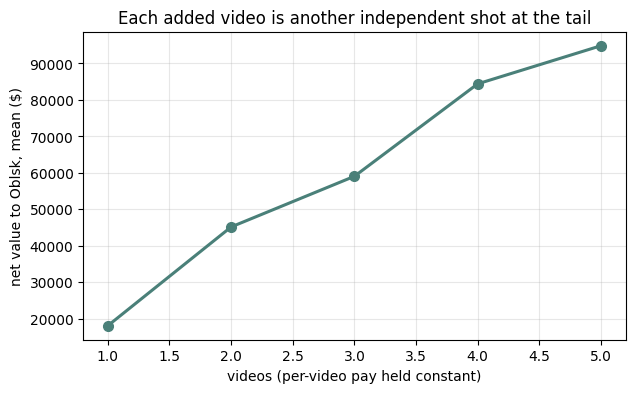

In [178]:
counts = [1, 2, 3, 4, 5]
# Hold the per-video rate fixed at the bundle's fair rate; add videos, each an independent draw.
nets = [ev_distribution(vm, Deal(video_count=k, flat_per_video=bundle.flat_per_video),
                        econ, n_samples=30000, seed=2).net_mean for k in counts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(counts, nets, '-o', color='#4a8079', lw=2.2, ms=7)
ax.set_xlabel('videos (per-video pay held constant)'); ax.set_ylabel('net value to Oblsk, mean ($)')
ax.set_title('Each added video is another independent shot at the tail')
ax.grid(alpha=0.3); plt.show()

## 3. A full negotiation, with a human approving each reply
The creator opens with questions, the agent answers from the brief, then leads with one clean flat number. When the creator pushes back, the agent reshapes the deal into a small bundle instead of nudging the price. Every outbound line waits for approval first.

In [179]:
o = run_negotiation(vm, econ, ctx, PERSONAS['inquisitive'](seed=2),
                    brief=brief, creator_name='Devin', verbose=True)
print('\n---')
print('result: %s in %d rounds, final $%s' % (o.status, o.rounds, o.final_total))

CREATOR: What would the deliverables be?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [answer_question]:
Hey Devin!

For this one we are looking at one in-feed Reel, 30 to 60 seconds, plus a story frame.

Anything else you want to know?
   why: Question about deliverables. Answer from the brief, stay in Q&A.

CREATOR: Got it, thanks. So what were you thinking for this?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [opening_flat]:
Hi Devin,

Your last few posts have been great. We'd love to have you on this campaign. We were thinking $2,250 for the video.

Let me know what you think.
   why: Open with one flat number, $2,250 for a single video (engaged, no number yet). ROI 10.8x. If rejected, go to a 3-video bundle.

CREATOR: Could you do $2,624 a video?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [escalate_bundle]:
Hey Devin,

Totally hear you on the rate. Here is something that might work better for both of us: $7,500 t

## 4. A creator the agent hands off
When a teammate rejects a proposed message, the agent does not improvise. It stops and the thread goes to a person. Same when the ask runs far past what the numbers support.

In [180]:
o = run_negotiation(vm, econ, ctx, PERSONAS['volume_friendly'](seed=1),
                    brief=brief, approver=reject_action('opening_flat'), verbose=True)
print('\n--- result:', o.status, '| human took over:', o.human_rejected)

CREATOR: Thanks for reaching out, I'd be interested. What did you have in mind?
   [human reviews -> REJECTED: human took over]

--- result: escalated | human took over: True


In [181]:
# An unreasonable ask: the creator wants about 3x what the numbers support.
from behavior_tree import decide, CreatorMessage, Intent
from behavior_tree import _flat_total
from state import NegotiationState
s = NegotiationState('c', 'k', 't')
decide(CreatorMessage(Intent.INTERESTED), s, vm, econ, ctx)        # agent opens flat
d = decide(CreatorMessage(Intent.NEGOTIATING, ask_total_usd=_flat_total(vm, econ, ctx) * 3,
                          raw_text='I would need around 7k for this'), s, vm, econ, ctx)
print('action:', d.action.value)
print('reason:', d.rationale)

action: escalate_human
reason: Ask $6,750 is more than 2x what the numbers support. A person should decide whether to walk or stretch.


## 5. Same agent, fully autonomous
Autonomy is one setting. In autonomous mode the same proposals send on their own, while big-dollar deals and unusual asks still route to a person.

In [182]:
o = run_negotiation(vm, econ, ctx, PERSONAS['easygoing'](seed=1),
                    brief=brief, autonomy=AutonomyLevel.AUTONOMOUS, verbose=True)
print('\n--- result:', o.status, '| approvals requested:', o.approvals_requested)

CREATOR: Thanks for reaching out, I'd be interested. What did you have in mind?

AGENT (sent) [opening_flat]:
Hi there,

Your last few posts have been great. We'd love to have you on this campaign. We were thinking $2,250 for the video.

Let me know what you think.
   why: Open with one flat number, $2,250 for a single video (engaged, no number yet). ROI 10.8x. If rejected, go to a 3-video bundle.

CREATOR: That works for me, let's do it.

AGENT [accept]: locking terms.

--- result: accepted | approvals requested: 0


## 6. How it does across creator types
A sweep over five temperaments and several seeds each. The agent should close the gettable deals, hold its line, and escalate the rest.

In [183]:
outcomes = []
for name in PERSONAS:
    for seed in range(20):
        vmk = fit_view_model(np.concatenate([np.random.default_rng(seed).lognormal(np.log(55000), 0.62, 22), [350000, 700000]]))
        outcomes.append(run_negotiation(vmk, econ, ctx, PERSONAS[name](seed=seed), brief=brief))
print(batch_metrics(outcomes).report())

n=100
  win rate                 77%
  autonomous-close rate    46%
  escalation rate          23%
  avg rounds to close      1.35
  avg discount from ask    9%
  avg final total          $4,242
  avg EV net (mean)        $23,758
  avg EV ROI               6.6x


## 7. New creators with less history
When a creator has too few posts to fit a model, the agent prices off a profile of similar creators, scaled to the few posts it has, and keeps going.

In [184]:
from ev_engine import synthetic_tier_prior
prior = synthetic_tier_prior(45000, size=1500)
thin = fit_view_model([41000, 58000], min_posts=6, prior_samples=prior)
print(thin.family, '|', thin.notes)
o = run_negotiation(thin, econ, ctx, PERSONAS['easygoing'](seed=3), brief=brief)
print('result:', o.status, '| final $%s' % o.final_total)

empirical_prior | fallback prior (2 posts, need 6); scaled x1.12
result: accepted | final $1900.0


## 8. Real-World Negotiation Example
In this example, we've tuned the agent to be more flexible and Riley to be firm but negotiable. Watch how the agent shifts from a flat offer to a bundle to bridge the gap.

In [185]:
import creator_sim
import runner
import importlib
from state import NegotiationState
importlib.reload(creator_sim)
importlib.reload(runner)

# HIGH ROI STRATEGY: Low opening, high-volume bundle, strict margin control
custom_ctx = CampaignContext(
    pay_fraction=0.18,         # Very aggressive opening (targeting ~15-20x ROI)
    auto_send_dollar_ceiling=20000,
    extreme_ask_multiple=4.0,
    roi_hurdle=3.5,            # High ROI requirement for auto-accept
    accept_margin=1.05         # Firm limit on how much we stretch
)

# Riley: Firm but negotiable enough to accept the bundle + sweetener
riley_demo = creator_sim.SimCreator(
    personality=creator_sim.Personality.PRICE_SENSITIVE,
    reservation_per_video=2200, # Lowered from 4000 to allow deal closure at agent's bundle rate
    counter_ratio=0.5,          # More responsive to the bundle framing
    rng_seed=42
)

def run_strategic_neg(*args, **kwargs):
    original_init = NegotiationState.__init__
    def new_init(self, *a, **k):
        original_init(self, *a, **k)
        self.max_rounds = 5
    NegotiationState.__init__ = new_init
    try:
        return runner.run_negotiation(*args, **kwargs)
    finally:
        NegotiationState.__init__ = original_init

o = run_strategic_neg(vm, econ, custom_ctx, riley_demo,
                      brief=brief, creator_name='Riley', verbose=True)

print('\n--- Final Result:', o.status.upper())
if o.status == 'accepted':
    print(f'Deal Closed at: ${o.final_total:,.0f} for {o.final_video_count} videos')
    print(f'Final Oblsk ROI: {o.final_ev_roi:.1f}x')
    print(f'Total Net Value: ${o.final_ev_net_mean:,.0f}')

CREATOR: Thanks for reaching out, I'd be interested. What did you have in mind?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [opening_flat]:
Hi Riley,

Your last few posts have been great. We'd love to have you on this campaign. We were thinking $1,350 for the video.

Let me know what you think.
   why: Open with one flat number, $1,350 for a single video (engaged, no number yet). ROI 18.0x. If rejected, go to a 3-video bundle.

CREATOR: Could you do $2,200 a video?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [escalate_bundle]:
Hey Riley,

Totally hear you on the rate. Here is something that might work better for both of us: $6,300 total for 3 videos ($2,100 each). A few videos tends to perform a lot better than a one-off, and it is a stronger package for you.

Let me know what you think.
   why: Flat rejected ($2,200). Hold a fair $2,100/video and offer 3 videos ($6,300 total). Net EV up about $29,692 from 2 more independent draws, ROI 9.4x

## 9. Try it yourself
Change the economics, the campaign knobs, or the creator and rerun.

In [186]:
# Re-importing to ensure updated creator_sim logic is loaded
import creator_sim
import runner
import importlib
importlib.reload(creator_sim)
importlib.reload(runner)

my_econ = CreatorEconomics(conversion_rate=0.002, ltv_usd=90)
my_ctx = CampaignContext(pay_fraction=0.30, auto_send_dollar_ceiling=3000)

# Run the negotiation with Riley again
o = runner.run_negotiation(vm, my_econ, my_ctx, creator_sim.PERSONAS['price_sensitive'](seed=7),
                           brief=brief, creator_name='Riley', verbose=True)
print('\n--- result:', o.status)

CREATOR: Thanks for reaching out, I'd be interested. What did you have in mind?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [opening_flat]:
Hi Riley,

Your last few posts have been great. We'd love to have you on this campaign. We were thinking $3,150 for the video.

Let me know what you think.
   why: Open with one flat number, $3,150 for a single video (engaged, no number yet). ROI 10.9x. If rejected, go to a 3-video bundle.

CREATOR: Could you do $7,000 a video?
   [human reviews -> approved: looks good]

AGENT (approved, sent) [escalate_human]:
Hi Riley,

Thanks for working through this with me. Let me check a couple of things on our side and come right back to you.
   why: Ask $7,000 is more than 2x what the numbers support. A person should decide whether to walk or stretch.


--- result: escalated
